# Oracle Model — Accuracy-Oriented Random Forest

A high-accuracy Random Forest trained on all completed W&B runs to act as simulated ground truth for convergence simulation. Unlike the acquisition surrogate (which maximizes tree diversity for σ̂ signal), the oracle maximizes predictive accuracy.

**Target hyperparams:** `max_features=None`, `max_samples=None` (full bootstrap), `n_estimators=512`, `min_samples_leaf=1`

In [1]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer
from src.utils.styled_tables import data_preview_styled
from IPython.display import Markdown

from typing import List

set_themes()
pl.Config.set_tbl_rows(20)

polars.config.Config

## Configuration

Define the target metric and the discrete hyperparameter space to enumerate over.

In [2]:
run_summary_file = "wandb/summary.parquet"

# Target metric spec — same format as model_based_parse_parameters
# Single metric: "epoch/test_recall@20"
# Weighted composite: "epoch/test_recall@20:0.7 epoch/test_ndcg@20:0.3"
target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"

# Hyperparameter columns to use as surrogate features.
# parameter_space (the list of discrete values per column) is derived automatically
# from completed runs in the Data Loading step below.
feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [3]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

# Compute target: best weighted composite score across epochs
# (same logic as model_based_parse_parameters in src/utils/config.py)
score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

# Derive parameter_space from unique observed values per feature column
parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


In [4]:
top_runs = (
    experiment_runs
    .sort(pl.col(target_metric), descending=True)
    .select(["run_id", "run_name", *feature_names, target_metric])
    .to_pandas()
)

data_preview_styled(
    top_runs,
    caption="Top runs by target score — best epoch test_recall@20 across all completed runs"
)

,run_id,run_name,embedding_dimension,shuffle,l1_regularization,l2_regularization,embedding_dropout_rate,target
0,kl4wqlfj,fallen-frost-6124,1024,False,1e-07,1e-07,0,0.0510807
1,06bqx7vi,spring-vortex-3451,512,False,1e-07,1e-07,0,0.0508812
2,ppnmplwp,light-vortex-4549,512,False,1e-07,1e-07,0,0.0508023
3,3f5jmpwt,crisp-sponge-5704,512,False,1e-07,1e-07,0,0.0508023
4,tc5m18b1,northern-wildflower-4878,512,False,1e-07,1e-07,0,0.0507871
5,th4pgbno,dark-elevator-3601,512,False,1e-07,1e-07,0,0.0507706
6,0287jiys,visionary-dust-4876,512,False,1e-07,1e-07,0,0.050766
7,xznge89i,zesty-mountain-5325,512,False,1e-07,1e-07,0,0.0507626
8,yir89nn4,eager-lake-6123,256,False,1e-07,1e-07,0,0.0507551
9,w1trw3q4,neat-field-5327,512,False,1e-07,1e-07,0,0.0507536


## Data Preparation

Extract X (hyperparameter features) and y (best checkpoint score) from the loaded runs. Rows with missing target values are dropped.

- `shuffle` is cast to float (True → 1.0, False → 0.0)
- `l1_regularization` and `l2_regularization` are kept in raw scale here. The **log₁₀ transform** is applied inside the sklearn `Pipeline` as the first step, so the raw values flow cleanly through all data preparation and grid enumeration steps.

In [5]:
# Keep only rows that have all feature columns and the target metric
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

# Cast shuffle (boolean) to float so sklearn is happy
full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Float64))

full_features = full_dataframe.select(feature_names).to_numpy()
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


### Run Density per Parameter Region

Before choosing a leave-one-region-out holdout, check how many runs exist per value of each feature. A good holdout region should have:
- Enough runs to make the evaluation meaningful (≥ 10)
- Cover a range of target scores (not all zeros or all best)
- Not be at the extreme of the space (otherwise the surrogate has no neighbours to generalise from)

In [6]:
# Run density per parameter region — count, mean, std, min, max of target score
from src.utils.styled_tables import data_preview_styled
from IPython.display import display

for col in feature_names:
    summary = (
        full_dataframe
        .group_by(col)
        .agg(
            pl.len().alias("n_runs"),
            pl.col(target_metric).mean().alias("mean_score"),
            pl.col(target_metric).std().alias("std_score"),
            pl.col(target_metric).min().alias("min_score"),
            pl.col(target_metric).max().alias("max_score"),
        )
        .sort(col)
    )
    display(data_preview_styled(
        summary.to_pandas(),
        caption=f"Run density — {col}"
    ))

,embedding_dimension,n_runs,mean_score,std_score,min_score,max_score
0,2,338,0.013443,0.0118992,0.000425755,0.0292629
1,4,293,0.0200285,0.0158695,0.000413417,0.0374408
2,8,276,0.0235321,0.0184333,0.000449044,0.0434386
3,16,261,0.0229431,0.0195534,0.000412689,0.0472051
4,32,273,0.0232647,0.0201828,0.000411988,0.0490338
5,64,361,0.0234604,0.0205648,0.000410302,0.0497937
6,128,487,0.0226751,0.0207202,0.000437045,0.0507021
7,256,363,0.0233303,0.0203385,0.000415255,0.0507551
8,512,348,0.0223596,0.0201198,0.000419744,0.0508812
9,1024,410,0.0222227,0.0200036,0.000398079,0.0510807


,shuffle,n_runs,mean_score,std_score,min_score,max_score
0,0,2272,0.0214743,0.0197549,0.000398079,0.0510807
1,1,1138,0.0222585,0.0183199,0.000410302,0.0500979


,l1_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1320,0.028931,0.0160959,0.00053644,0.0494515
1,1e-10,62,0.038684,0.00441301,0.0247856,0.0429082
2,1e-09,329,0.0323038,0.0151901,0.00165781,0.049774
3,1e-08,313,0.0318416,0.015683,0.00163111,0.0501882
4,1e-07,347,0.0352187,0.0165576,0.000738772,0.0510807
5,1e-06,295,0.000828726,0.000143465,0.000398079,0.00146874
6,1e-05,306,0.000670791,0.000101764,0.000413417,0.000980718
7,0.0001,298,0.000594325,4.60195e-05,0.000508673,0.00075964
8,0.001,72,0.000634661,2.9106e-05,0.000571359,0.000725075
9,0.01,68,0.000655063,4.09864e-05,0.000600912,0.000841356


,l2_regularization,n_runs,mean_score,std_score,min_score,max_score
0,0,1345,0.0254883,0.0180393,0.000508673,0.0481629
1,1e-10,56,0.0384051,0.00491479,0.0236655,0.0431684
2,1e-09,294,0.0258825,0.0192037,0.000521569,0.0482935
3,1e-08,303,0.0266934,0.0192814,0.000521914,0.0483897
4,1e-07,337,0.0301132,0.0211946,0.000517333,0.0510807
5,1e-06,312,0.0262776,0.0202885,0.000539916,0.0457204
6,1e-05,309,0.00881289,0.00885273,0.000413417,0.0261704
7,0.0001,315,0.00244037,0.00174603,0.000398079,0.0081746
8,0.001,71,0.000664741,7.17899e-05,0.00053644,0.00082273
9,0.01,68,0.00152737,0.000407259,0.000760497,0.00239232


,embedding_dropout_rate,n_runs,mean_score,std_score,min_score,max_score
0,0,2575,0.0199577,0.0196509,0.000398079,0.0510807
1,0.1,60,0.0383361,0.00546677,0.0219445,0.0437118
2,0.2,58,0.0383097,0.00632784,0.0197022,0.0449339
3,0.3,60,0.0382748,0.00644093,0.0206895,0.0448783
4,0.4,360,0.0218636,0.0200383,0.000486882,0.0470823
5,0.5,63,0.0370134,0.00727223,0.0165025,0.0437209
6,0.6,60,0.034982,0.00756476,0.0171414,0.0431936
7,0.7,58,0.0324964,0.00731701,0.0156488,0.0407066
8,0.8,58,0.0269155,0.00681717,0.011032,0.0352224
9,0.9,58,0.00279929,0.00084473,0.00194933,0.00576348


## Oracle Model Training

Fit a **Random Forest Regressor** with accuracy-oriented hyperparams. The oracle serves as simulated ground truth for convergence simulation.

- `max_features=None` — each tree sees all features (no feature subsampling)
- `max_samples=None` — full bootstrap (default, each tree sees ~63% of samples)
- `n_estimators=512` — enough trees for stable predictions
- `min_samples_leaf=1` — deep trees for maximum accuracy

`oob_score=True` gives an out-of-bag R² estimate without needing a held-out split.

In [7]:
# Oracle: accuracy-oriented RF (no diversity tricks)
oracle = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=512,
        max_features=None,
        max_samples=None,
        min_samples_leaf=1,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

oracle.fit(full_features, full_target)
print(f"OOB R²: {oracle.named_steps['rf'].oob_score_:.4f}")

OOB R²: 0.9990


## Model Evaluation — Leave-Cliff-Out

Hold out runs at or across the two performance cliffs (l1=1e-6/1e-7, l2=1e-5/1e-6). This forces the oracle to extrapolate across the performance discontinuities — the hardest test of predictive accuracy.

In [17]:
# Test set: runs at or across either performance cliff
mask_cliff = (
    full_dataframe["l1_regularization"].is_in([1e-7, 1e-6])
    | full_dataframe["l2_regularization"].is_in([1e-6, 1e-5])
)

train_dataframe = full_dataframe.filter(~mask_cliff)
test_dataframe  = full_dataframe.filter(mask_cliff)

train_features = train_dataframe.select(feature_names).to_numpy()
train_target   = train_dataframe[target_metric].to_numpy()
test_features  = test_dataframe.select(feature_names).to_numpy()
test_target    = test_dataframe[target_metric].to_numpy()

print(f"Train size: {len(train_dataframe):,}  |  Test size (cliff runs): {len(test_dataframe):,}")
print(f"Test target range: [{test_target.min():.4f}, {test_target.max():.4f}]")
print()

oracle_eval = Pipeline([
    ("log_reg", Log10Transformer(feature_names)),
    ("rf", RandomForestRegressor(
        n_estimators=512,
        max_features=None,
        max_samples=None,
        min_samples_leaf=1,
        oob_score=False,
        n_jobs=-1,
        random_state=42,
    )),
])
oracle_eval.fit(train_features, train_target)
predicted_target = oracle_eval.predict(test_features)

print(f"Held-out R²  : {r2_score(test_target, predicted_target):.4f}")
print(f"Held-out MAE : {mean_absolute_error(test_target, predicted_target):.4f}")
 
# Rank-based metrics — the simulation only needs correct ordering
from scipy.stats import spearmanr

spearman_rho, _ = spearmanr(test_target, predicted_target)
print(f"Spearman ρ   : {spearman_rho:.4f}")

for k in [50, 100, 200]:
    ideal_order = np.argsort(-test_target)[:k]
    ideal_dcg = sum(
        (2 ** test_target[i] - 1) / np.log2(j + 2) for j, i in enumerate(ideal_order)
    )
    pred_order = np.argsort(-predicted_target)[:k]
    dcg = sum(
        (2 ** test_target[i] - 1) / np.log2(j + 2) for j, i in enumerate(pred_order)
    )
    ndcg = dcg / ideal_dcg if ideal_dcg > 0 else 0.0
    print(f"NDCG@{k:<8d}: {ndcg:.4f}")

Train size: 2,301  |  Test size (cliff runs): 1,109
Test target range: [0.0004, 0.0511]

Held-out R²  : 0.9136
Held-out MAE : 0.0029
Spearman ρ   : 0.9461
NDCG@50      : 0.9248
NDCG@100     : 0.9389
NDCG@200     : 0.9684


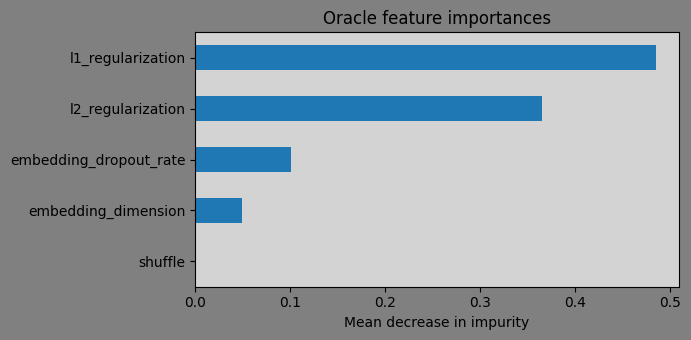

In [18]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(7, 3.5))
importances = pd.Series(
    oracle_eval.named_steps["rf"].feature_importances_, index=feature_names
).sort_values(ascending=True)
importances.plot.barh(ax=ax)
ax.set_xlabel("Mean decrease in impurity")
ax.set_title("Oracle feature importances")
plt.tight_layout()
plt.show()